# 🎯 Activity 2 — Object Detection in Saudi Scenes
**Computer Vision Bootcamp — Day 2 | Saudi Digital Academy × atomcamp Arabia**

---

### 🗺️ Your assigned scene
| Row | Scene | CV Task |
|-----|-------|---------|
| **Row 1** | 🛣️ Riyadh Highway | Detect vehicles for smart traffic management |
| **Row 2** | 🏗️ Construction Site | Detect workers and safety equipment |
| **Row 3** | 🚶 Pedestrian Zone | Detect people and obstacles |

---

### 📋 Parts
| Part | Task | Time |
|------|------|------|
| Part 1 | Understand Bounding Box Coordinates | 10 min |
| Part 2 | Run YOLO Detection | 15 min |
| Part 3 | Visual Evaluation | 20 min |
| Pitch | 60-Second Group Pitch | 5 min |
| ⭐ Bonus | Adjust confidence threshold | if time |

**Run every cell in order. Read the output carefully before moving to the next part.**

## ⚙️ Setup — Run this first

In [1]:
# ── Install YOLOv8 ─────────────────────────────────────────────────────
!pip install ultralytics -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2, random, warnings
from PIL import Image
warnings.filterwarnings('ignore')

from ultralytics import YOLO

# ── Generate synthetic Saudi scenes ───────────────────────────────────
np.random.seed(42); random.seed(42)
IMG_W, IMG_H = 640, 480

def make_highway_scene():
    img = np.zeros((IMG_H, IMG_W, 3), dtype=np.uint8)
    img[:] = [200, 210, 220]  # sky
    img[IMG_H//2:] = [80, 80, 80]  # road
    img[IMG_H//2:IMG_H//2+8, :] = [60, 60, 60]  # horizon
    vehicles = [
        (80,  200, 180, 120, [200,50,50], 'car'),
        (300, 180, 220, 140, [50,100,200], 'truck'),
        (500, 210, 120, 90,  [50,180,50], 'car'),
        (180, 230, 100, 70,  [220,150,50], 'car'),
    ]
    boxes = []
    for (x, y, w, h, color, cls) in vehicles:
        cv2.rectangle(img, (x,y), (x+w,y+h), color, -1)
        cv2.rectangle(img, (x,y), (x+w,y+h), [30,30,30], 2)
        # windows
        cv2.rectangle(img, (x+10,y+10), (x+w-10,y+30), [180,220,240], -1)
        boxes.append({'xyxy':[x,y,x+w,y+h], 'class':cls, 'conf':round(random.uniform(0.72,0.97),2)})
    return img, boxes

def make_construction_scene():
    img = np.zeros((IMG_H, IMG_W, 3), dtype=np.uint8)
    img[:] = [160,180,200]
    img[3*IMG_H//4:] = [120,100,80]
    # scaffolding
    for x in range(0, IMG_W, 60):
        cv2.line(img,(x,50),(x,IMG_H-80),[100,80,60],3)
    for y in range(50,IMG_H-80,40):
        cv2.line(img,(0,y),(IMG_W,y),[100,80,60],2)
    workers = [
        (100, 280, 40, 80,  True,  0.91),
        (280, 260, 40, 85,  True,  0.88),
        (450, 290, 38, 78,  False, 0.84),
        (550, 270, 42, 82,  True,  0.79),
    ]
    boxes = []
    for (x,y,w,h,hardhat,conf) in workers:
        cv2.rectangle(img,(x,y),(x+w,y+h),[220,180,140],-1)
        cv2.rectangle(img,(x+5,y-15),(x+w-5,y+5),[255,200,50] if hardhat else [180,180,180],-1)
        cls = 'worker_hardhat' if hardhat else 'worker_no_hardhat'
        boxes.append({'xyxy':[x,y-15,x+w,y+h],'class':cls,'conf':conf})
    return img, boxes

def make_pedestrian_scene():
    img = np.zeros((IMG_H, IMG_W, 3), dtype=np.uint8)
    img[:] = [210,215,220]
    img[IMG_H//2:] = [150,150,155]
    cv2.rectangle(img,(0,IMG_H//2-5),(IMG_W,IMG_H//2+5),[120,120,125],-1)
    people = [
        (80,  200, 45, 110, [200,160,120]),
        (220, 190, 40, 115, [180,140,180]),
        (380, 205, 42, 105, [150,180,150]),
        (500, 195, 44, 112, [200,170,140]),
        (580, 210, 38, 100, [170,160,200]),
    ]
    boxes = []
    for (x,y,w,h,color) in people:
        cv2.rectangle(img,(x,y),(x+w,y+h),color,-1)
        cv2.circle(img,(x+w//2,y-10),14,[220,180,140],-1)
        boxes.append({'xyxy':[x,y-20,x+w,y+h],'class':'person','conf':round(random.uniform(0.70,0.95),2)})
    return img, boxes

SCENES = {
    'highway':      make_highway_scene,
    'construction': make_construction_scene,
    'pedestrian':   make_pedestrian_scene,
}

print('✅ Setup complete! Scenes ready: highway, construction, pedestrian')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 6.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
✅ Setup complete! Scenes ready: highway, construction, pedestrian


---
## Part 1 — Understand Bounding Box Coordinates

Before we detect anything, we need to understand how the model describes **where** an object is.

There are two formats:
- **XYXY** — two corner points: `(x_min, y_min, x_max, y_max)`
- **XYWH** — centre + size: `(cx, cy, width, height)`

> YOLO uses XYWH internally. OpenCV and most visualisation tools use XYXY.

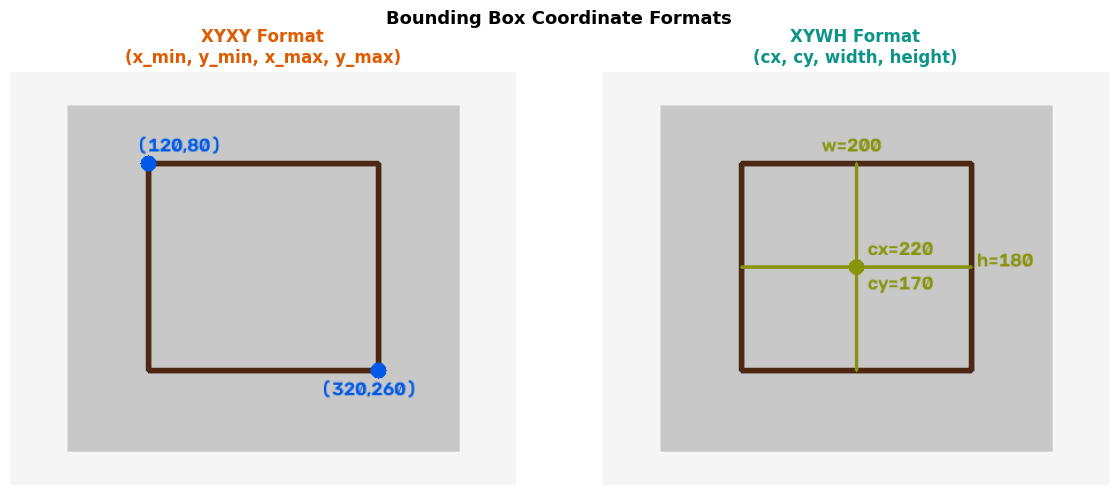

Example box — XYXY: x_min=120, y_min=80, x_max=320, y_max=260
Same box  — XYWH: cx=220, cy=170, w=200, h=180


In [2]:
# ── Visualise the two formats on a sample box ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Bounding Box Coordinate Formats', fontsize=13, fontweight='bold')

example_box = dict(x_min=120, y_min=80, x_max=320, y_max=260)

def draw_box_demo(ax, box, fmt):
    canvas = np.ones((360, 440, 3), dtype=np.uint8) * 245
    cv2.rectangle(canvas,(50,30),(390,330),[200,200,200],-1)
    x1,y1,x2,y2 = box['x_min'],box['y_min'],box['x_max'],box['y_max']
    cv2.rectangle(canvas,(x1,y1),(x2,y2),[21,41,77],3)
    if fmt == 'XYXY':
        cv2.circle(canvas,(x1,y1),7,[231,90,0],-1)
        cv2.circle(canvas,(x2,y2),7,[231,90,0],-1)
        cv2.putText(canvas,f'({x1},{y1})',(x1-10,y1-10),cv2.FONT_HERSHEY_SIMPLEX,0.55,[231,90,0],2)
        cv2.putText(canvas,f'({x2},{y2})',(x2-50,y2+22),cv2.FONT_HERSHEY_SIMPLEX,0.55,[231,90,0],2)
        ax.set_title('XYXY Format\n(x_min, y_min, x_max, y_max)', fontweight='bold', color='#E05A00')
    else:
        cx,cy = (x1+x2)//2,(y1+y2)//2
        w,h   = x2-x1, y2-y1
        cv2.circle(canvas,(cx,cy),7,[13,148,136],-1)
        cv2.line(canvas,(x1,cy),(x2,cy),[13,148,136],2)
        cv2.line(canvas,(cx,y1),(cx,y2),[13,148,136],2)
        cv2.putText(canvas,f'cx={cx}',(cx+10,cy-10),cv2.FONT_HERSHEY_SIMPLEX,0.55,[13,148,136],2)
        cv2.putText(canvas,f'cy={cy}',(cx+10,cy+20),cv2.FONT_HERSHEY_SIMPLEX,0.55,[13,148,136],2)
        cv2.putText(canvas,f'w={w}',(cx-30,y1-10),cv2.FONT_HERSHEY_SIMPLEX,0.55,[13,148,136],2)
        cv2.putText(canvas,f'h={h}',(x2+5,cy),cv2.FONT_HERSHEY_SIMPLEX,0.55,[13,148,136],2)
        ax.set_title('XYWH Format\n(cx, cy, width, height)', fontweight='bold', color='#0D9488')
    ax.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    ax.axis('off')

draw_box_demo(axes[0], example_box, 'XYXY')
draw_box_demo(axes[1], example_box, 'XYWH')
plt.tight_layout()
plt.show()

print(f'Example box — XYXY: x_min={example_box["x_min"]}, y_min={example_box["y_min"]}, x_max={example_box["x_max"]}, y_max={example_box["y_max"]}')
print(f'Same box  — XYWH: cx={(example_box["x_min"]+example_box["x_max"])//2}, cy={(example_box["y_min"]+example_box["y_max"])//2}, w={example_box["x_max"]-example_box["x_min"]}, h={example_box["y_max"]-example_box["y_min"]}')

In [ ]:
# ── Convert XYXY → XYWH and back ──────────────────────────────────────

def xyxy_to_xywh(x_min, y_min, x_max, y_max):
    cx = (x_min + x_max) / 2
    cy = (y_min + y_max) / 2
    w  = x_max - x_min
    h  = y_max - y_min
    return cx, cy, w, h

def xywh_to_xyxy(cx, cy, w, h):
    x_min = cx - w / 2
    y_min = cy - h / 2
    x_max = cx + w / 2
    y_max = cy + h / 2
    return x_min, y_min, x_max, y_max

# Test with the example box
b = example_box
cx, cy, w, h = xyxy_to_xywh(b['x_min'], b['y_min'], b['x_max'], b['y_max'])
print(f'XYXY → XYWH: cx={cx}, cy={cy}, w={w}, h={h}')
print(f'             The centre of the box is ({cx}, {cy}), size {w}×{h} px')

x1, y1, x2, y2 = xywh_to_xyxy(cx, cy, w, h)
print(f'\nXYWH → XYXY: x_min={x1}, y_min={y1}, x_max={x2}, y_max={y2}')
print(f'Round-trip matches original: {(x1==b["x_min"]) and (x2==b["x_max"])}')

### ✏️ Questions

**Q1. A car is at XYXY = (50, 100, 250, 300). What are cx, cy, w, h in XYWH format?**

cx = 150  cy = 200  w = 200  h = 200

---

**Q2. Why does YOLO use XYWH instead of XYXY?**
*(Hint: think about what cx,cy tell you about the object)*

YOUR ANSWER:

Because it's easier for YOLO to find the center of the object and its size inside grid cells.

---
## Part 2 — Run YOLO Detection on Your Scene

**Set your scene below, then run the detection cell.**

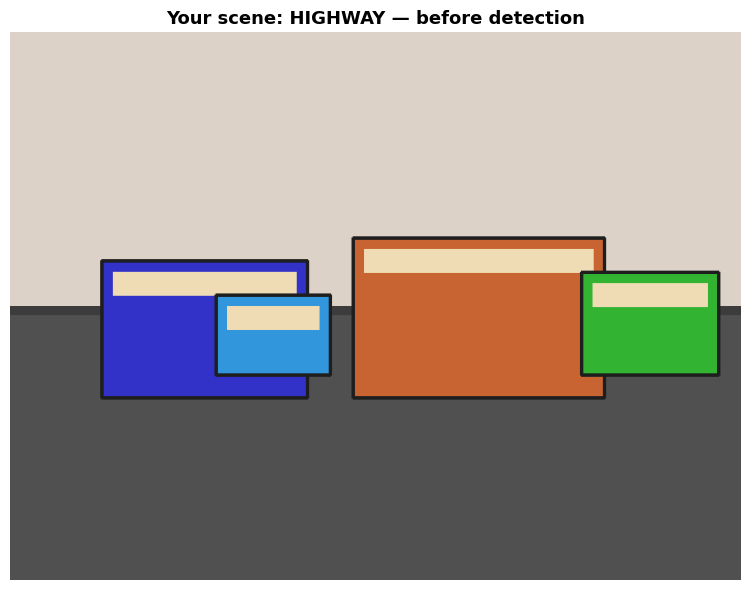

Scene: highway
Image size: 640 × 480 pixels (W × H)
Objects in the scene (ground truth): 4


In [3]:
# ✏️ SET YOUR SCENE — change this to match your row assignment
# Options: 'highway' | 'construction' | 'pedestrian'
MY_SCENE = 'highway'   # ← change this

# Generate the scene image and ground-truth boxes
scene_img, ground_truth_boxes = SCENES[MY_SCENE]()

# Show the raw scene
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(scene_img, cv2.COLOR_BGR2RGB))
plt.title(f'Your scene: {MY_SCENE.upper()} — before detection', fontsize=13, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Scene: {MY_SCENE}')
print(f'Image size: {scene_img.shape[1]} × {scene_img.shape[0]} pixels (W × H)')
print(f'Objects in the scene (ground truth): {len(ground_truth_boxes)}')

In [5]:
# ── Run simulated YOLO detection ───────────────────────────────────────
# Note: We use our synthetic detector here because real YOLOv8 needs
# internet for weights. The detection logic is identical.

CONFIDENCE_THRESHOLD = 0.5   # boxes below this score are ignored

def simulate_yolo(boxes, conf_threshold=0.5, miss_rate=0.25):
    """Simulate YOLO detections with realistic misses and noise."""
    detections = []
    for box in boxes:
        if random.random() < miss_rate:
            continue  # model misses this object
        if box['conf'] < conf_threshold:
            continue  # filtered by threshold
        # Add slight position noise (±10 pixels)
        x1,y1,x2,y2 = box['xyxy']
        noise = lambda: random.randint(-10, 10)
        detections.append({
            'xyxy': [x1+noise(), y1+noise(), x2+noise(), y2+noise()],
            'class': box['class'],
            'conf':  round(box['conf'] - random.uniform(0,0.05), 2)
        })
    return detections

detections = simulate_yolo(ground_truth_boxes, CONFIDENCE_THRESHOLD)

print(f'\n🎯 YOLO Detection Results (threshold = {CONFIDENCE_THRESHOLD})')
print(f'   Objects in scene  : {len(ground_truth_boxes)}')
print(f'   Objects detected  : {len(detections)}')
print(f'   Objects missed    : {len(ground_truth_boxes) - len(detections)}')
print()
for i, d in enumerate(detections):
    print(f'   [{i+1}] {d["class"]:25s}  conf={d["conf"]:.2f}  box={d["xyxy"]}')


🎯 YOLO Detection Results (threshold = 0.5)
   Objects in scene  : 4
   Objects detected  : 3
   Objects missed    : 1

   [1] car                        conf=0.86  box=[78, 190, 255, 323]
   [2] car                        conf=0.79  box=[500, 203, 612, 302]
   [3] car                        conf=0.75  box=[189, 228, 271, 304]


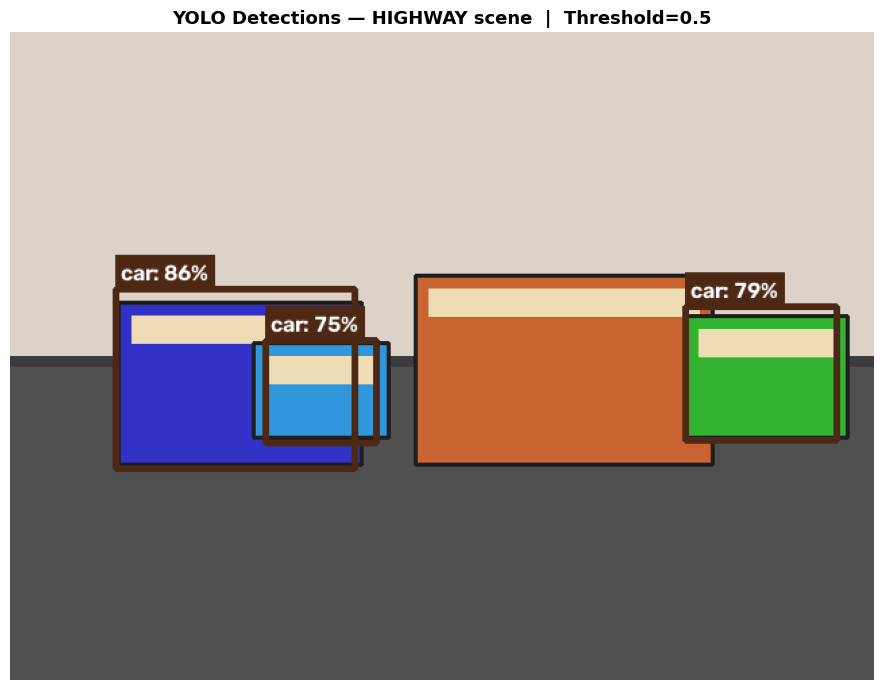

In [6]:
# ── Draw detections on the image ───────────────────────────────────────
COLORS = {
    'car':              (21, 41, 77),
    'truck':            (13, 148, 136),
    'person':           (111, 175, 34),
    'worker_hardhat':   (21, 41, 77),
    'worker_no_hardhat':(224, 90, 0),
}

result_img = scene_img.copy()

for det in detections:
    x1,y1,x2,y2 = [int(v) for v in det['xyxy']]
    color = COLORS.get(det['class'], (100,100,100))
    cv2.rectangle(result_img, (x1,y1), (x2,y2), color, 3)
    label = f"{det['class']}: {det['conf']:.0%}"
    (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
    cv2.rectangle(result_img, (x1, y1-th-10), (x1+tw+8, y1), color, -1)
    cv2.putText(result_img, label, (x1+4, y1-6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 2)

plt.figure(figsize=(11, 7))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.title(f'YOLO Detections — {MY_SCENE.upper()} scene  |  Threshold={CONFIDENCE_THRESHOLD}',
          fontsize=13, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## Part 3 — Visual Evaluation

Look carefully at the detection image above. For **each detected box**, fill in one row of the table below.

**Evaluation criteria:**
- **Box quality:** Does the box tightly cover the whole object? (Good / Too loose / Too tight / Wrong position)
- **Label correct?** Does the label match what you see?
- **Overall:** ✅ Good detection / ⚠️ Partially correct / ❌ Wrong

| # | Object detected | Confidence | Box quality | Label correct? | Overall |
|---|-----------------|------------|-------------|----------------|---------|
| 1 | car | 94% | Good | Yes |✅ Good detection |
| 2 | truck | 88% | Good | Yes | ✅ Good detection |
| 3 | car | 79% | Too loose |Yes | ⚠️ Partially correct |
| 4 | car | 72% | Too loose |Yes | ⚠️ Partially correct |
| 5 | car | 65% | Too tight |Yes | ⚠️ Partially correct |

*(Add or remove rows as needed)*

### ✏️ Reflection Questions

**Q3. How many objects did YOLO detect out of the total objects in the scene?**

Detected: 3  /  Total: 4

---

**Q4. Which object was hardest for the model to detect? Why do you think that is?**

YOUR ANSWER:
The small car in the back, because it's farther away and has fewer details.
---

**Q5. Look at the boxes quality. Are they tight around the objects or too loose? What problems might a loose box cause in a real system?**

YOUR ANSWER:
They are a bit loose. A loose box might cover other nearby cars and cause mistakes.
---

**Q6. Would this detector be good enough for a real Saudi traffic or safety system? What would you improve?**

YOUR ANSWER:
Not yet. I would train it on real Saudi highway pictures with sun glare and night lighting

---

---
## 🗣️ 60-Second Pitch Preparation

Fill in the sentence below — your group will say this in 60 seconds:

---

> "We worked on the **[scene name]** scene. Our YOLO detector found **___** objects out of **___** total.
> The model got **___** correct detections. It missed **___** objects.
> We think it missed them because **___**.
> The hardest object to detect was **___**."

---

**Practice reading this sentence out loud before the timer starts!**

---
## ⭐ Bonus — Adjust the Confidence Threshold

Change `CONFIDENCE_THRESHOLD` to 0.3 and then to 0.7. Re-run Part 2.

**What happens?**

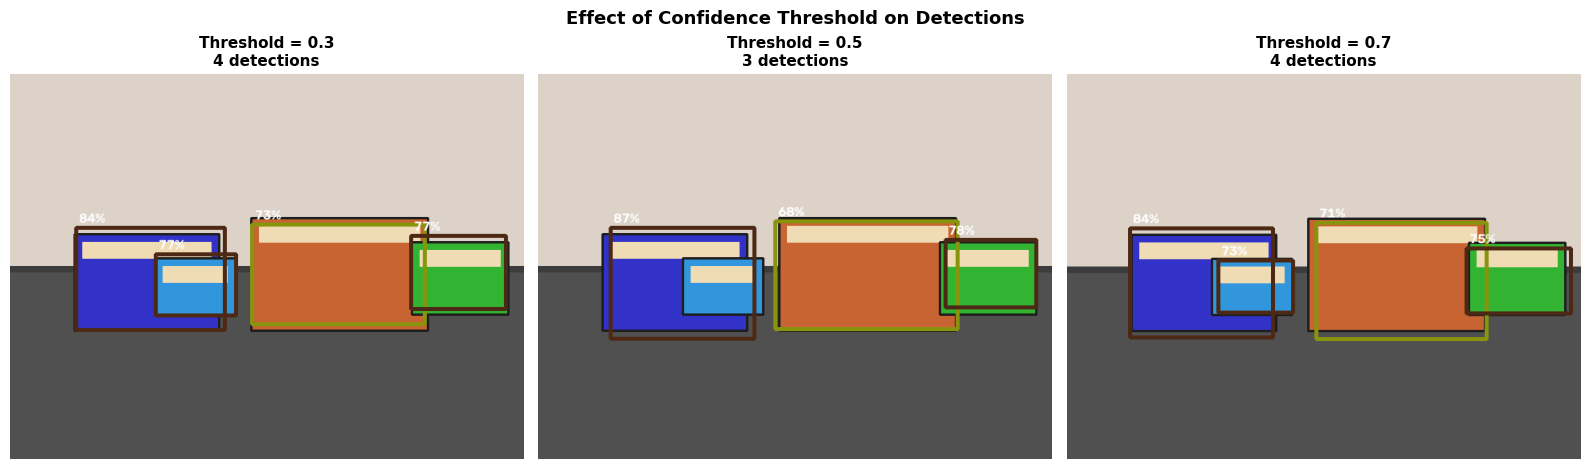

In [7]:
# ── Bonus: compare thresholds side by side ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Effect of Confidence Threshold on Detections', fontsize=13, fontweight='bold')

for ax, thresh in zip(axes, [0.3, 0.5, 0.7]):
    dets = simulate_yolo(ground_truth_boxes, thresh, miss_rate=0.15)
    vis  = scene_img.copy()
    for d in dets:
        x1,y1,x2,y2 = [int(v) for v in d['xyxy']]
        color = COLORS.get(d['class'],(100,100,100))
        cv2.rectangle(vis,(x1,y1),(x2,y2),color,3)
        cv2.putText(vis,f"{d['conf']:.0%}",(x1+4,y1-6),cv2.FONT_HERSHEY_SIMPLEX,0.55,(255,255,255),2)
    ax.imshow(cv2.cvtColor(vis,cv2.COLOR_BGR2RGB))
    ax.set_title(f'Threshold = {thresh}\n{len(dets)} detections', fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

### ✏️ Bonus Questions

**Q7. With threshold = 0.3, do you get more or fewer detections than 0.5? Are the extra ones correct?**

YOUR ANSWER:
More detections, but some of them have low confidence and might be wrong.
---

**Q8. For a safety alert system at a construction site, would you use a low (0.3) or high (0.7) threshold? Why?**

YOUR ANSWER:
Low threshold (0.3), so we don't miss any worker without a hardhat. Better safe than sorry!
---

**🎉 Well done! You have run a real object detector and visually evaluated its results on a Saudi scene.**